# Intrusion Error Rate

> Track how often recalls include items not on the current study list.

An intrusion error occurs when a participant recalls an item that was not presented on the current study list. The intrusion error rate curve plots the proportion of intrusion errors at each output position, revealing where in the recall sequence participants are most likely to produce extra-list items.

## Workflow

In [1]:
import os
import matplotlib.pyplot as plt
import warnings
from jaxcmr.analyses.intrusion_error_rate import plot_intrusion_error_rate
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

warnings.filterwarnings("ignore")

In [2]:
data_path = "data/RepeatedRecallsKahanaJacobs2000.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['listLength'] > 0"
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

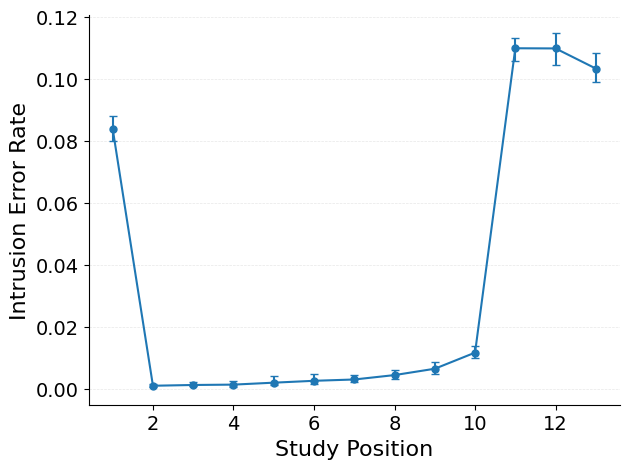

In [4]:
plot_intrusion_error_rate(datasets=data, trial_masks=trial_mask, confidence_level=confidence_level)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

## Interpretation

The x-axis shows output position and the y-axis shows the proportion of recalls at that position that are intrusion errors. Key patterns:

- **Rising trend**: intrusion rates typically increase across output positions as the pool of correct items is exhausted.
- **High baseline**: elevated intrusion rates throughout may indicate list discrimination difficulty.

## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset`.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `ylim` — y-axis limits as a tuple, or `None` for automatic scaling.
- `trial_query` — a Python expression evaluated against the dataset to select trials.
- `confidence_level` — confidence level for subject-wise error bars.
